In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn  # torch.nn contains everything needed to build neural networks like layers, loss functions ,activation functions
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [2]:
# This is a powerplant dataset from the energy industry and the output is energy produced by the powerplants
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT => temperature
# V => vacuum
# AP => pressure
# RH => humidity

# PE => produced energy (output)

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE",axis=1)
y = df["PE"]

In [7]:
# Split Our Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
df.shape

(9568, 5)

### Scaling/Normalizing Data

In [9]:
# Scaling/normalizing data is important for neural networks because it makes training faster and prevents features with large values from 
# dominating smaller ones

# Example:
# Suppose x1 is in range 0–10 and x2 is in range 0–10000. In the linear combination z = x1*w1 + x2*w2 + b,
# x2 has a much larger scale, so it will dominate the value of z.This makes the model biased toward x2 and slows down learning.

# To avoid this, we use StandardScaler (or normalization) so that all features are on a similar scale.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # fit_transform() returns a NumPy array, not a DataFrame
X_test_scaled = scaler.transform(X_test)

In [10]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

### Converting Data into Tensors

In [11]:
type(X_train) # Before Scaling it is a pandas DataFrame. A table-like structure (rows & columns with labels)

pandas.core.frame.DataFrame

In [12]:
type(X_train_scaled) # After Scaling it is a NumPy array because fit_transform() returns a NumPy array, not a DataFrame. 
# This is just raw numerical data (no column names, just values)

numpy.ndarray

In [13]:
type(y_train)

pandas.core.series.Series

In [14]:
# why pandas series in not passed in torch.tensor?
# Passing a Pandas Series to torch.tensor() may work, but it’s unreliable, so we convert it to a NumPy array using .values to avoid errors

In [15]:
y_train.shape

(7654,)

In [16]:
# .view(-1,1) is used to reshape the tensor into 2D

# here -1 → PyTorch automatically decides the number of rows
# and 1 → number of columns = 1

# initially y_train shape is (7654,) → which is a 1D tensor (no columns)
# but PyTorch models expect target in shape (n,1), i.e., (7654,1)

# so we convert:
# [1, 2, 3, 4]  → shape (4,)

# into:
# [
#  [1],
#  [2],
#  [3],
#  [4]
# ] → shape (4,1)

# so now y_train shape becomes (7654,1)
# where 7654 is automatically determined by PyTorch


In [17]:
# Generally In deep learning, data is usually converted to float because neural networks require precise numerical computations

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
# .values is used to convert a pandas series into a NumPy array so it can be properly converted into a PyTorch tensor

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)
# By default, tensors are stored in the computer's RAM (CPU memory)

In [18]:
y_train_tensor.shape # here you can observe that the shape is changed

torch.Size([7654, 1])

### Creating Dataset and DataLoader

In [19]:
# Creating Datasets
# TensorDataset is a PyTorch class that wraps input and target tensors together so they can be accessed as pairs and used with a DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [20]:
# Creating DataLoader(DataLoader class work is to define how the data will be loaded fro training)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

### Deep Learning

In [21]:
# Define our ANN Model
# We build our ANN model as a class, and it is built on top of nn.Module(base class) because we inherit from it
# nn.Module is a base (parent) class in PyTorch, already provided for creating neural networks
# It acts as the foundation for all neural network models and provides built-in features like parameter tracking, training support, and GPU compatibility.
# nn.Module contains the necessary mechanisms for forward propagation and supports backpropagation (gradient computation) that we can inherit in our custom model(ANN)

In [28]:
class ANN(nn.Module): # Defines a class named ANN that inherits from nn.Module
    # Self is reference to the object
    def __init__(self): # init is a constructor(It is a special function that runs automatically when you create an object)
        super(ANN, self).__init__() # calls the constructor of the parent class nn.Module to initialize the neural network
        # super(ANN,self) means find the parent class of ANN and use it for this object (self)

        # self.model is an instance variable that stores the neural network (layers) inside the class and when an object is created, 
        # it initializes this model inside the object, which is then used during forward propagation
        self.model = nn.Sequential( # A container that arranges layers one after another (in sequence)
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),  # computes the weighted sum of inputs and adds a bias
            nn.ReLU(), # introduces non-linearity
    
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6, 1),
        )

    def forward(self, x): # defines how data flows through your neural network
        return self.model(x) # x is the input data to your neural network

In [29]:
# In PyTorch, we explicitly define the forward propagation using the forward() function, but we do not manually implement backward propagation
# PyTorch’s autograd system automatically computes the gradients when we call loss.backward()  [Interview Question]

In [30]:
model = ANN()

# loss, optimizer

crietrion = nn.MSELoss() # is used to create a loss function object that calculates the Mean Squared Error (MSE), also known as the L2 loss
# This is a standard loss function primarily used for regression problems. 
optimizer = optim.Adam(model.parameters()) # updates all learnable parameters of the model, including both weights and biases, using gradients to minimize the loss

### Training the ANN

In [31]:
# We train our ANN for multiple epochs (1 epoch means the model sees the entire training dataset once) 
# Each epoch consists of multiple batches, and for each batch, we perform forward propagation, compute loss, perform backward propagation, 
# and update the weights and biases

In [32]:
epochs = 100
train_losses = []
val_losses = []

best_val_loss = float("inf") # Initialize with infinite value

for epoch in range(epochs):
    model.train() # model.train() sets the model to training mode. This is a crucial step because certain layers, like Dropout and Batch Normalization, behave differently during training and evaluation
    running_loss = 0.0 # total training loss for 1 epoch

    for xb, yb in train_loader: # applying loop on all batches of training dataset and passing batch on by one to neural netwrok for forward and backward propagation
        # xb = features of 1 batch
        # yb = labels of 1 batch
        
        optimizer.zero_grad() # clears previously accumulated gradients so that new gradients can be computed correctly in the current iteration
        
        outputs = model(xb) # Forward Propagation step.... predicted outputs for this batch
        loss = crietrion(outputs,yb) # Computing loss
        loss.backward() # backward propagation...compute gradients
        optimizer.step() # function that updates the model's parameters (weights and biases) based on the gradients calculated during the backward propagation

        running_loss += loss.item() # this loss value is calcualted by pytorch so it is bydefault a tensor value so we need to convert it into python float value
        # loss is a tensor => py float

        
    epoch_train_loss = running_loss/len(train_loader) # average loss over all batches in an epoch = total loss from all batches in that epoch/number of batches
    train_losses.append(epoch_train_loss)


    # Validation (At time of validation we will not do backward propagation)
    model.eval() # sets your neural network into evaluation mod
    running_val_loss = 0.0

    # During training we adjust weights (learn parameters), but during validation/testing weights are already learned, so we don’t do 
    # backpropagation ,we only do forward propagation and loss calculation.
    
    with torch.no_grad(): # PyTorch automatically computes gradients during operations, but inside with torch.no_grad(), we tell it not to compute or track gradients
        # by using torch.no_grad we our saving memory(gradient computations are not stored) and the below step will work faster
        # So we mostly write this torch.no_grad() when we do validation or testing
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth is a common extension for PyTorch models
        # torch.save() A function that saves data to disk
        # model.state_dict() Returns a dictionary and contains all learnable parameters of the model (weights & biases)

epoch 1/100 ==> train loss = 205584.98782552083 & val loss = 202886.046875
epoch 2/100 ==> train loss = 194997.585546875 & val loss = 182867.296875
epoch 3/100 ==> train loss = 162826.78287760416 & val loss = 138817.03125
epoch 4/100 ==> train loss = 111191.21988932292 & val loss = 83614.0859375
epoch 5/100 ==> train loss = 60533.60402832031 & val loss = 41460.640625
epoch 6/100 ==> train loss = 30192.58269042969 & val loss = 22257.935546875
epoch 7/100 ==> train loss = 18584.62773844401 & val loss = 15796.693359375
epoch 8/100 ==> train loss = 14310.69198404948 & val loss = 12588.3408203125
epoch 9/100 ==> train loss = 11488.78687133789 & val loss = 9998.6396484375
epoch 10/100 ==> train loss = 9044.458038330078 & val loss = 7689.8232421875
epoch 11/100 ==> train loss = 6849.363385009766 & val loss = 5666.25439453125
epoch 12/100 ==> train loss = 4965.637889607748 & val loss = 3987.4716796875
epoch 13/100 ==> train loss = 3440.324193318685 & val loss = 2672.481689453125
epoch 14/100 =

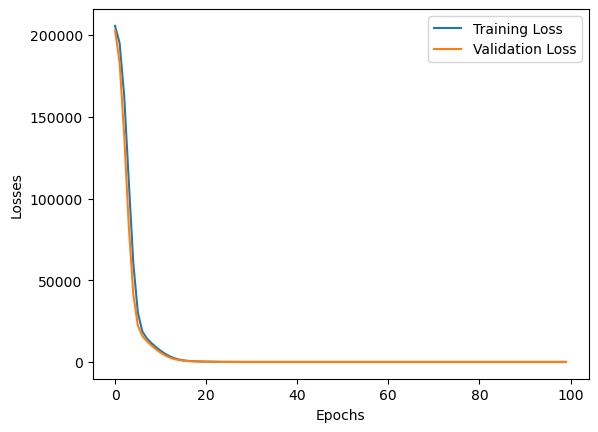

In [33]:
loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

### Saving and Loading Best Model

In [34]:
# In each epoch, the model learns different parameters such as weights and biases. We need to find the best model across multiple epochs
# The best model is the one where the loss is minimal
# We focus on minimizing validation loss because it reflects how well the model performs on unseen data
# If we only minimize training loss, it can lead to overfitting
# Therefore, we monitor validation data to determine at which epoch the neural network performs best
# So, we can say: Best model = model with minimum validation loss
# Now we will save the best model to memory(the computer’s disk) as a file
# We store the learnable parameters (weights and biases) in this file
# These parameters are saved in the form of a dictionary

model.load_state_dict(torch.load("best_model.pt"))
# torch.load("best_model.pt") Loads the saved file from disk and returns the dictionary containing weights and biases
# model.load_state_dict(...) Takes that dictionary and loads it into your model and updates the model’s parameters with the saved (trained) values

<All keys matched successfully>

### Evaluation

In [37]:
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor) # Here we are using X_train_tensor not train_loader because for evaluation(we need full dataset at once)
    # and in training we were using train_loader because we were training in batches ,same for X_test_tensor
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 19.139039993286133
Testing MSE: 18.035503387451172


In [40]:
# R^2 score
print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9369705719101535


In [41]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,436.302490,433.27
1,436.477875,438.16
2,461.583130,458.42
3,475.655792,480.82
4,436.637024,441.41
...,...,...
1909,450.972229,456.70
1910,432.237976,438.04
1911,466.578064,467.80
1912,431.422058,437.14
